# Whakaari Dataset

This notebook builds the Whakaari case-study dataset for Cause–Trigger analysis. It combines waveform-derived hydrothermal/seismic features with weather, gas, and deformation variables on a common hourly grid.

In [1]:
import sys
from pathlib import Path
import pandas as pd
from obspy.clients.fdsn import Client

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src/whakaari"
sys.path.append(str(SRC_DIR))

from whakaari_config import (
    WHAKAARI_START,
    WHAKAARI_END,
    WHAKAARI_ERUPTION_TIME,
    TILDE_DATA_URL,
    WHAKAARI_LAT,
    WHAKAARI_LON,
    WHAKAARI_WAVEFORM_CONFIG,
    whakaari_observable_metadata,
)

from whakaari_geonet import (
    load_gnss_deformation,
    load_weather_vars,
)

from whakaari_waveform import build_waveform_dataset

from whakaari_dataset import (
    build_master_dataframe,
    prepare_raw_analysis_dataframe,
    build_final_causal_dataframe,
    save_whakaari_datasets,
    preprocessing_report,
)

from whakaari_plotting_utils import (
    WHAKAARI_ALL_COLS,
    dataset_health_report,
    plot_variable_pdfs,
    distribution_summary,
    plot_whakaari_all_variables_map,
    plot_whakaari_thesis_figures,
    plot_whakaari_loglog_distributions,
)

client = Client("GEONET")

BUFFER_START = (
    pd.Timestamp(WHAKAARI_START, tz="UTC") - pd.Timedelta(days=2)
).strftime("%Y-%m-%d")

## GeoNet and external data

We retrieve GNSS deformation from GeoNet/Tilde, and hourly weather variables from Open-Meteo. Antecedent Precipitation Index (API) and pressure drop are derived as hydrothermal forcing proxies.

In [2]:
gnss = load_gnss_deformation(
    tilde_data_base_url=TILDE_DATA_URL,
    start=BUFFER_START,
    end=WHAKAARI_END,
)

weather_vars = load_weather_vars(
    lat=WHAKAARI_LAT,
    lon=WHAKAARI_LON,
    start=BUFFER_START,
    end=WHAKAARI_END,
    cache_path="../data/whakaari/whakaari_openmeteo_weather.csv",
    redownload=True, # True to force redownloading, False to use cached dataset
)

## Waveform feature extraction

Waveform data from WSRZ are processed into hourly seismic features: hydrothermal tremor RMS, spectral ratio, HF event rate, and a positive tremor-response anomaly variable.

In [3]:
WHAKAARI_WAVEFORM_PKL = "../data/whakaari/whakaari_waveform.pkl"

waveform_df, waveform_failures = build_waveform_dataset(
    client=client,
    start=WHAKAARI_START,
    end=WHAKAARI_END,
    cfg=WHAKAARI_WAVEFORM_CONFIG,
    save_path=WHAKAARI_WAVEFORM_PKL,
    overwrite=False, # True will re-download and process waveforms, False will load from pkl
)

loaded cached waveform dataset: ..\data\whakaari\whakaari_waveform.pkl


## Final hourly dataset

All variables are aligned to a common hourly timeline. Missing values are handled according to variable type, and the final dataset is saved in raw and scaled forms.

In [4]:
whakaari_master = build_master_dataframe(
    wave=waveform_df,
    weather_vars=weather_vars,
    gnss=gnss,
    start=WHAKAARI_START,
    end=WHAKAARI_END,
)

whakaari_raw = prepare_raw_analysis_dataframe(whakaari_master)

whakaari_final = build_final_causal_dataframe(
    whakaari_raw
)

save_whakaari_datasets(
    whakaari_raw=whakaari_raw,
    whakaari_final=whakaari_final,
    output_dir="../data/whakaari",
)

## Distribution diagnostics & preprocessing summary

Empirical density plots and summary statistics are used to inspect skewness, outliers, and scaling behavior. 


Whakaari analysis dataset
shape: (1733, 7)
duplicate timestamps: 0
time sorted: True

Missing fraction:
hydro_2_5                0.0
ratio_4p5_8_over_8_16    0.0
event_rate_2_5           0.0
effect_tremor_5_15       0.0
rain_12h_sum             0.0
pressure_drop            0.0
GNSS_deformation         0.0
dtype: float64
Whakaari analysis dataset


,count,mean,std,min,median,max,skew,n_unique,missing_fraction
GNSS_deformation,1733.0,0.012839,0.003083,4.500000e-03,0.013020,0.021210,-0.074843,73,0.0
effect_tremor_5_15,1733.0,0.089461,0.287725,0.000000e+00,0.009998,6.875234,14.599602,949,0.0
event_rate_2_5,1733.0,10.515868,19.842899,0.000000e+00,6.000000,193.000000,5.881431,85,0.0
hydro_2_5,1733.0,0.000006,0.000120,6.244219e-07,0.000002,0.004080,30.677283,1733,0.0
pressure_drop,1733.0,-0.002308,0.452483,-1.800000e+00,0.000000,1.800000,0.078751,57,0.0
rain_12h_sum,1733.0,1.181708,3.500575,0.000000e+00,0.000000,29.200000,4.593393,191,0.0
ratio_4p5_8_over_8_16,1733.0,1.628933,0.449586,5.267378e-01,1.736905,2.665916,-0.556408,1331,0.0


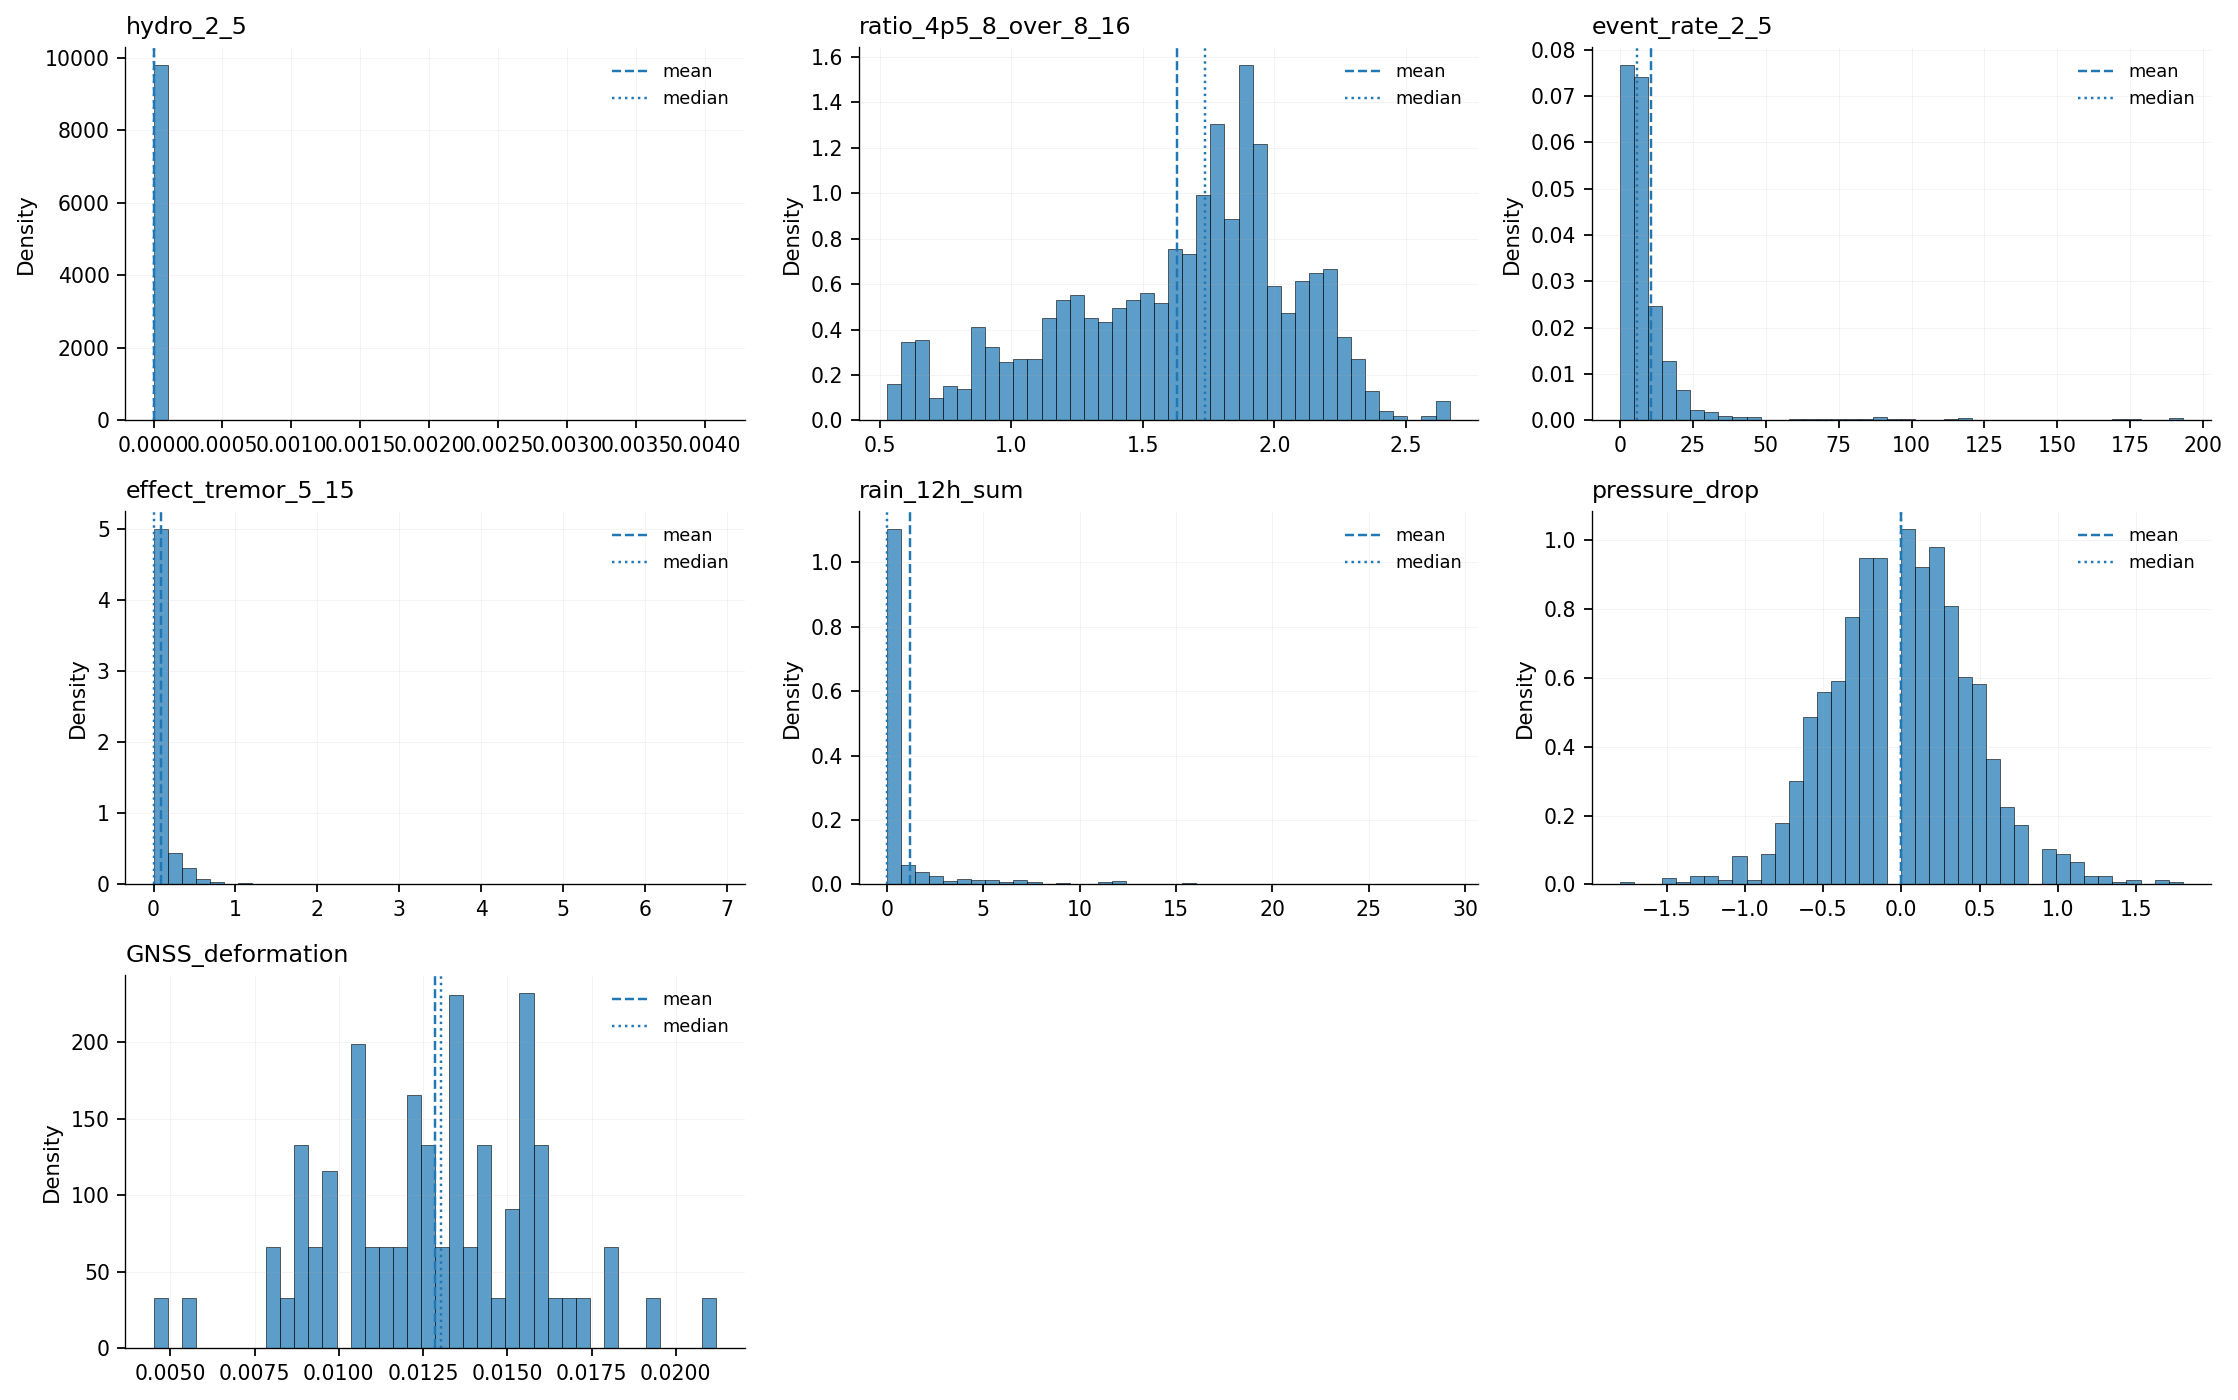

(<Figure size 2256x1440 with 9 Axes>,
 array([<Axes: title={'left': 'hydro_2_5'}, ylabel='Density'>,
        <Axes: title={'left': 'ratio_4p5_8_over_8_16'}, ylabel='Density'>,
        <Axes: title={'left': 'event_rate_2_5'}, ylabel='Density'>,
        <Axes: title={'left': 'effect_tremor_5_15'}, ylabel='Density'>,
        <Axes: title={'left': 'rain_12h_sum'}, ylabel='Density'>,
        <Axes: title={'left': 'pressure_drop'}, ylabel='Density'>,
        <Axes: title={'left': 'GNSS_deformation'}, ylabel='Density'>,
        <Axes: >, <Axes: >], dtype=object))

In [5]:
dataset_health_report(whakaari_raw, "Whakaari analysis dataset")

display(distribution_summary(whakaari_raw, "Whakaari analysis dataset"))

plot_variable_pdfs(
    whakaari_raw,
    name="",
    cols=WHAKAARI_ALL_COLS,
    bins=40,
    filename="whakaari_pdf.png"
)

In [6]:
preprocessing_summary = preprocessing_report(
    rawest_df=whakaari_master,
    prepared_df=whakaari_raw,
)


Preprocessing summary
---------------------
Rows before preprocessing: 1752
Rows after preprocessing:  1733
Rows dropped:              19

Dropped timestamps:
  2019-10-01 00:00:00+00:00
  2019-10-01 01:00:00+00:00
  2019-10-01 02:00:00+00:00
  2019-10-01 03:00:00+00:00
  2019-10-01 04:00:00+00:00
  2019-10-01 05:00:00+00:00
  2019-10-01 06:00:00+00:00
  2019-10-01 07:00:00+00:00
  2019-10-01 08:00:00+00:00
  2019-10-01 09:00:00+00:00
  2019-10-01 10:00:00+00:00
  2019-10-01 11:00:00+00:00
  2019-11-18 23:00:00+00:00
  2019-11-19 00:00:00+00:00
  2019-11-19 01:00:00+00:00
  2019-11-19 02:00:00+00:00
  2019-11-19 03:00:00+00:00
  2019-11-19 04:00:00+00:00
  2019-11-19 05:00:00+00:00

Variables with preprocessing changes:


,variable,status,missing_before,missing_after,filled_from_nan,changed_existing,lost_by_dropped_rows
0,GNSS_deformation,kept,0,0,0,0,19
1,effect_tremor_5_15,kept,16,0,0,0,3
2,event_rate_2_5,kept,4,0,0,0,15
3,hydro_2_5,kept,4,0,0,0,15
4,pressure_drop,kept,0,0,0,0,19
5,rain_12h_sum,kept,0,0,0,0,19
6,ratio_4p5_8_over_8_16,kept,6,0,0,0,13


### Whakaari raw-variable log-log distributions

a visual diagnostic for scale, tails, and zero inflation.

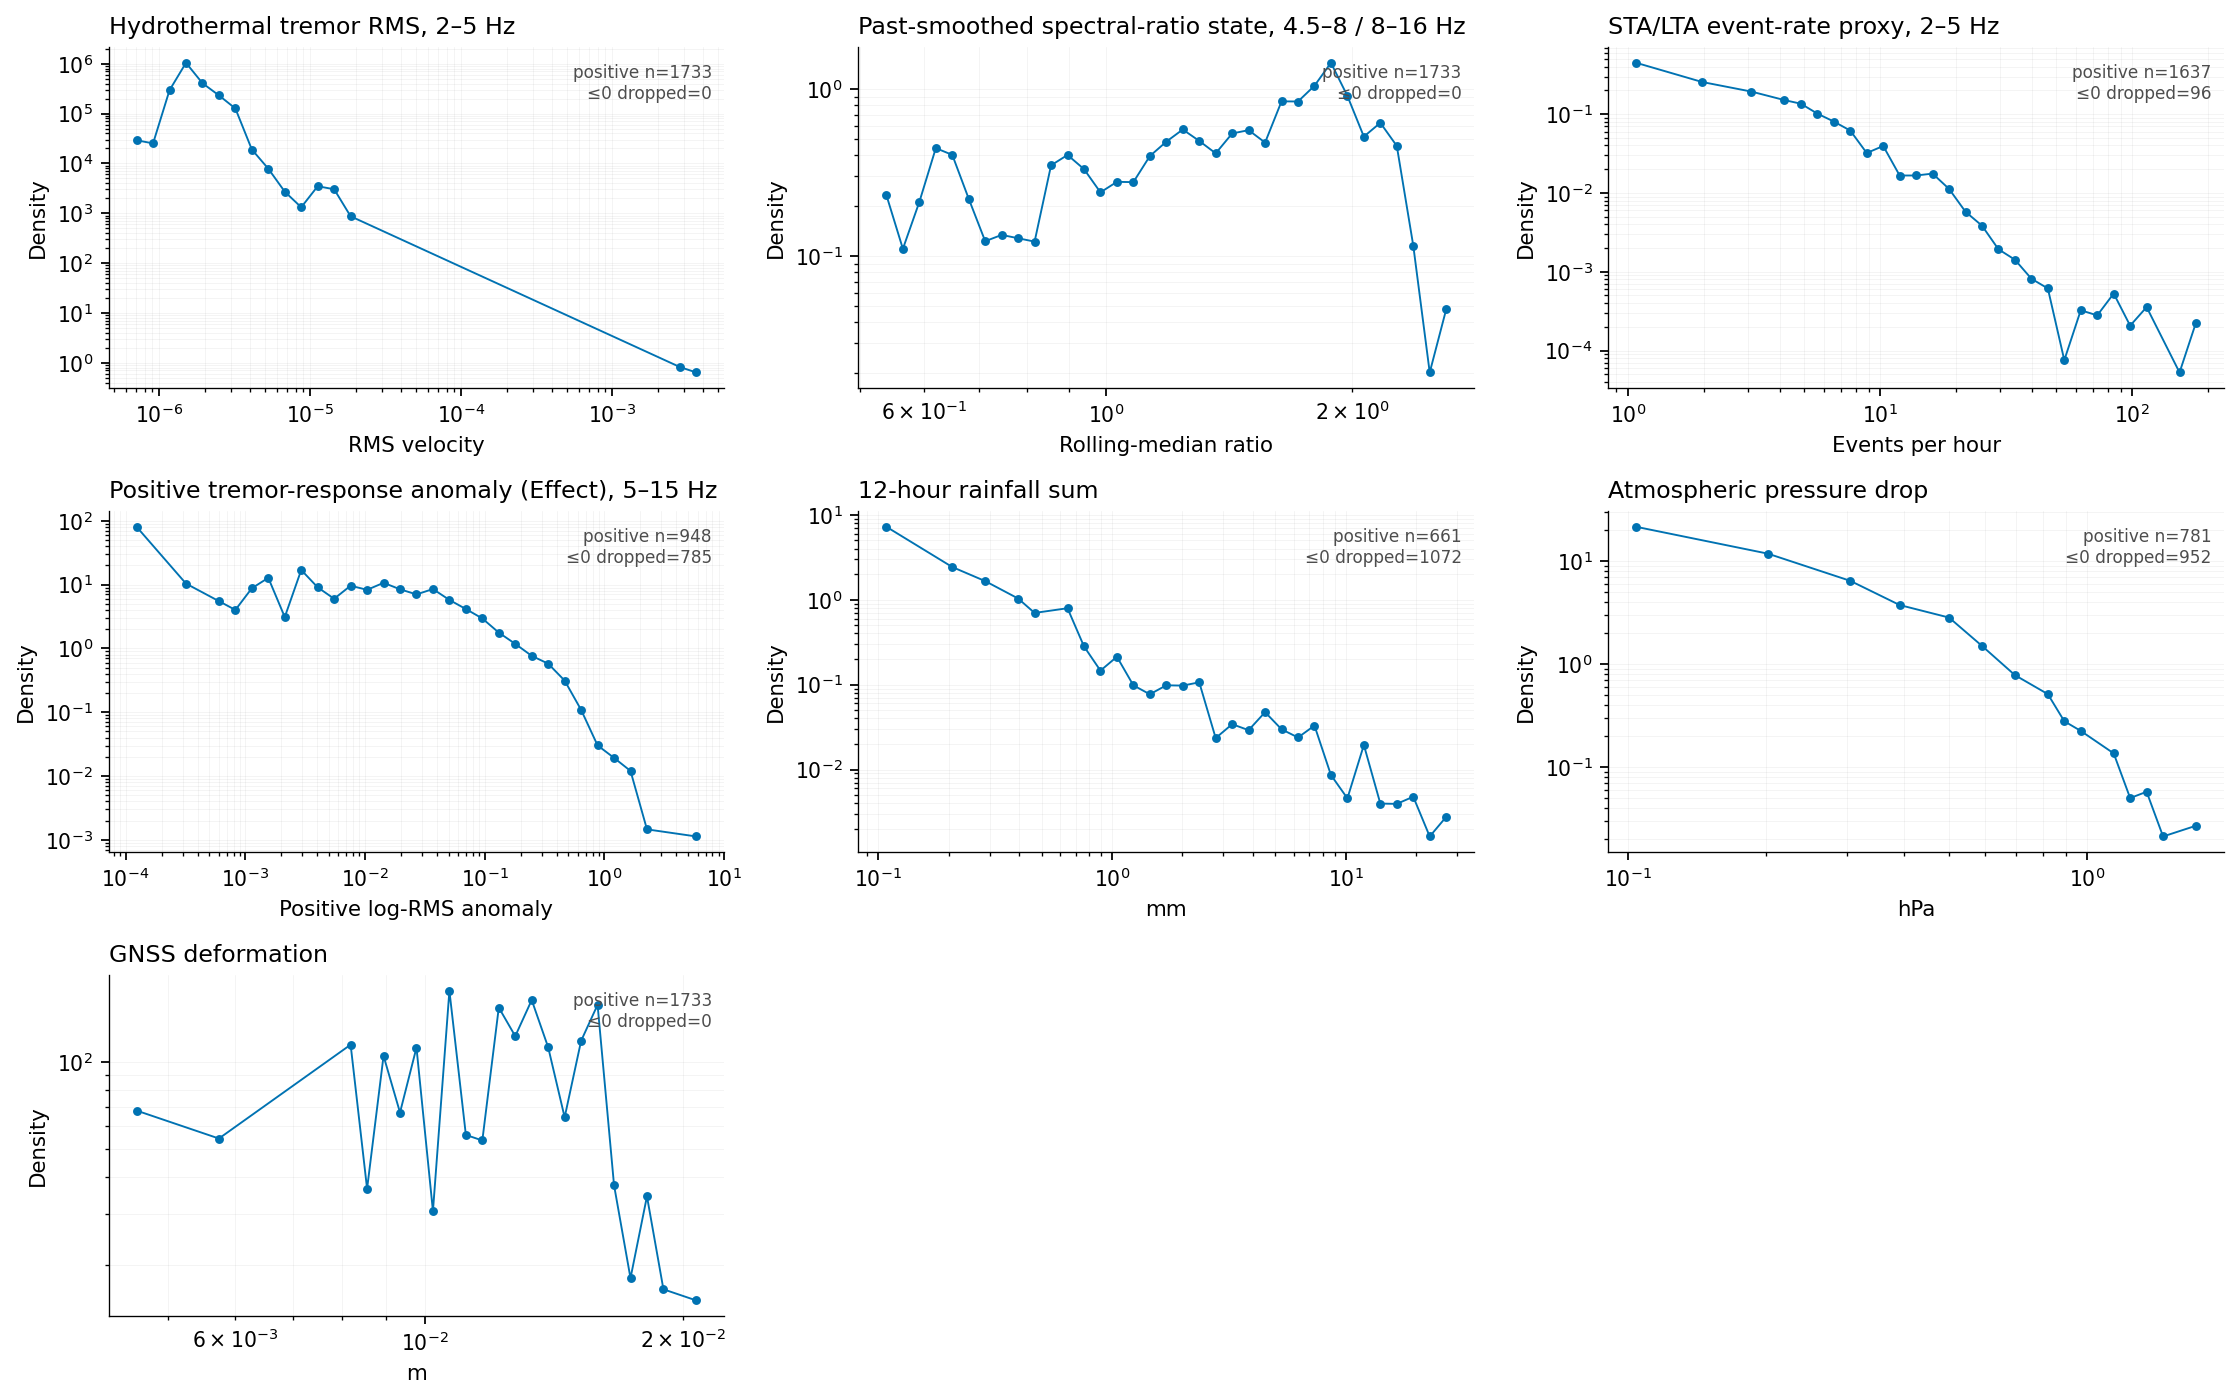

,variable,n_total_nonmissing,n_positive_used,n_nonpositive_dropped,positive_fraction,min_positive,max_positive,n_unique_positive
0,hydro_2_5,1733,1733,0,1.000000,6.244219e-07,0.004080,1733
1,ratio_4p5_8_over_8_16,1733,1733,0,1.000000,5.267378e-01,2.665916,1331
2,event_rate_2_5,1733,1637,96,0.944605,1.000000e+00,193.000000,84
3,effect_tremor_5_15,1733,948,785,0.547028,1.056147e-04,6.875234,948
4,rain_12h_sum,1733,661,1072,0.381420,1.000000e-01,29.200000,190
5,pressure_drop,1733,781,952,0.450664,1.000000e-01,1.800000,29
6,GNSS_deformation,1733,1733,0,1.000000,4.500000e-03,0.021210,73


In [7]:
fig, axes, whakaari_loglog_report = plot_whakaari_loglog_distributions(
    whakaari_raw.reset_index(),
    save_dir="figures",
)

display(whakaari_loglog_report)

In [8]:
model_cols = [c for c in whakaari_final.columns if c != "time"]
scaled_check = whakaari_final[model_cols].agg(["mean", "std", "min", "max"]).T
scaled_check["std_ddof0"] = whakaari_final[model_cols].std(ddof=0)

display(scaled_check)
display(whakaari_final[model_cols].abs().max().sort_values(ascending=False))

,mean,std,min,max,std_ddof0
hydro_2_5_scaled,7.216129e-16,1.000289,-2.081302,14.803193,1.0
ratio_4p5_8_over_8_16_scaled,-3.280059e-17,1.000289,-3.208238,1.654348,1.0
event_rate_2_5_scaled,1.968035e-16,1.000289,-2.097410,3.622458,1.0
effect_tremor_5_15_scaled,2.050037e-17,1.000289,-0.311013,23.591021,1.0
rain_12h_sum_scaled,2.460044e-17,1.000289,-0.512704,4.323625,1.0
pressure_drop_scaled,9.225165e-18,1.000289,-3.236819,3.249856,1.0
GNSS_deformation_scaled,1.968035e-16,1.000289,-2.705490,2.715721,1.0


effect_tremor_5_15_scaled       23.591021
hydro_2_5_scaled                14.803193
rain_12h_sum_scaled              4.323625
event_rate_2_5_scaled            3.622458
pressure_drop_scaled             3.249856
ratio_4p5_8_over_8_16_scaled     3.208238
GNSS_deformation_scaled          2.715721
dtype: float64

## Final hourly dataset with event marker

The final variables are plotted with the eruption time marked. To assess whether the causal-analysis window and variables are physically meaningful.

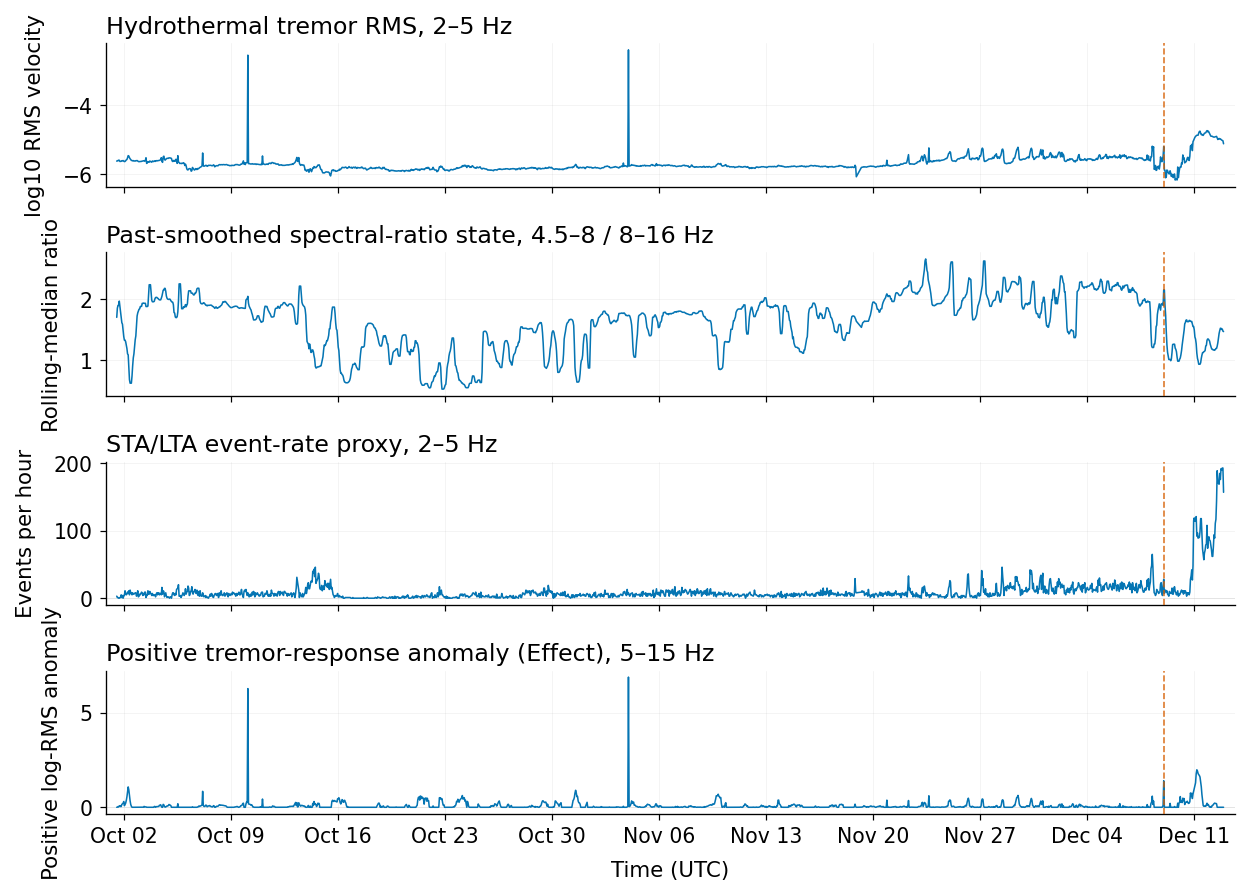

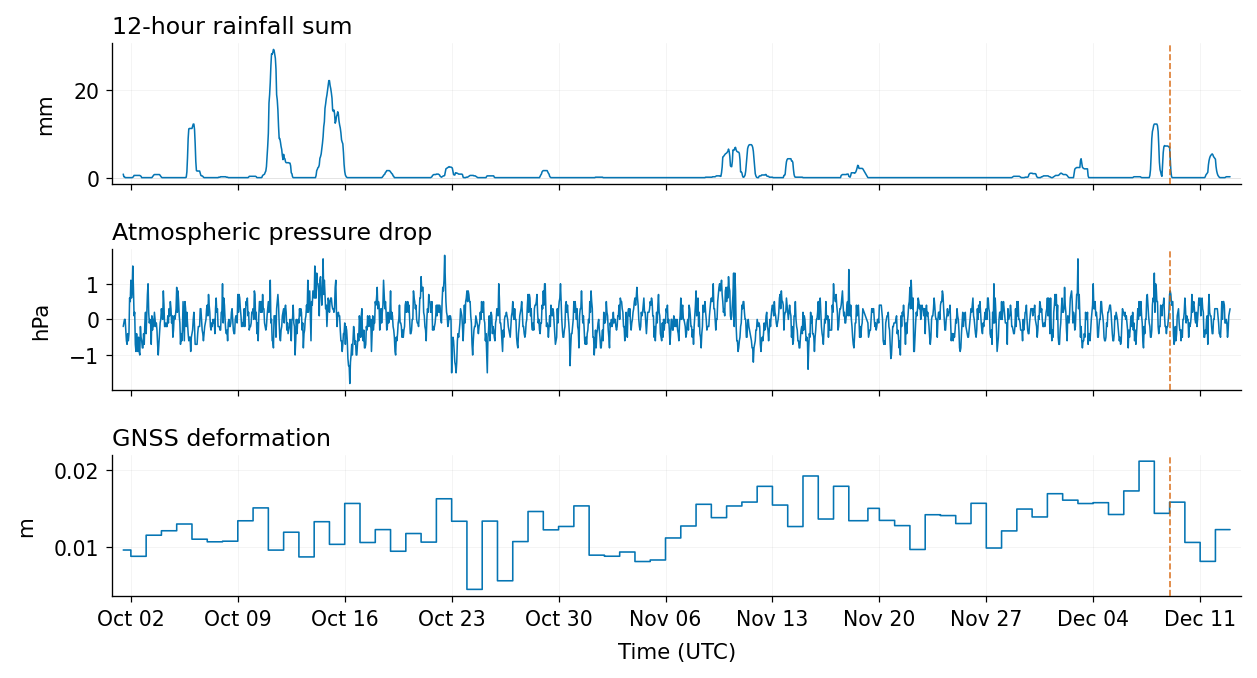

((<Figure size 1280x860.8 with 4 Axes>,
  array([<Axes: title={'left': 'Hydrothermal tremor RMS, 2–5 Hz'}, ylabel='log10 RMS velocity'>,
         <Axes: title={'left': 'Past-smoothed spectral-ratio state, 4.5–8 / 8–16 Hz'}, ylabel='Rolling-median ratio'>,
         <Axes: title={'left': 'STA/LTA event-rate proxy, 2–5 Hz'}, ylabel='Events per hour'>,
         <Axes: title={'left': 'Positive tremor-response anomaly (Effect), 5–15 Hz'}, xlabel='Time (UTC)', ylabel='Positive log-RMS anomaly'>],
        dtype=object)),
 (<Figure size 1280x617.6 with 3 Axes>,
  array([<Axes: title={'left': '12-hour rainfall sum'}, ylabel='mm'>,
         <Axes: title={'left': 'Atmospheric pressure drop'}, ylabel='hPa'>,
         <Axes: title={'left': 'GNSS deformation'}, xlabel='Time (UTC)', ylabel='m'>],
        dtype=object)))

In [9]:
plot_whakaari_thesis_figures(
    csv_path="../data/whakaari/whakaari_raw.csv",
    eruption_time=WHAKAARI_ERUPTION_TIME,
    save_dir="figures",
    include_titles=False,
    display_transform={
        "hydro_2_5": "log10",
    },
)

## Geographic Visualization

c:\Users\cescedes\Desktop\Distinguishing Causes and Triggers in Volcanic and Seismic Processes\src\whakaari\whakaari_plotting_utils.py:748: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  label_rows = pd.concat([centres, reference_df], ignore_index=True)


,Source,Source ID,Variables,Internal names
0,Open-Meteo,WHAKAARI_OPENMETEO_PROXY,Atmospheric pressure drop; 12-hour rainfall sum,"pressure_drop, rain_12h_sum"
1,RGWC–RGWI GNSS,RGWC_RGWI,GNSS deformation proxy,GNSS_deformation
2,WSRZ,WSRZ,"Positive tremor-response anomaly, 5–15 Hz; Hig...","effect_tremor_5_15, event_rate_2_5, hydro_2_5,..."


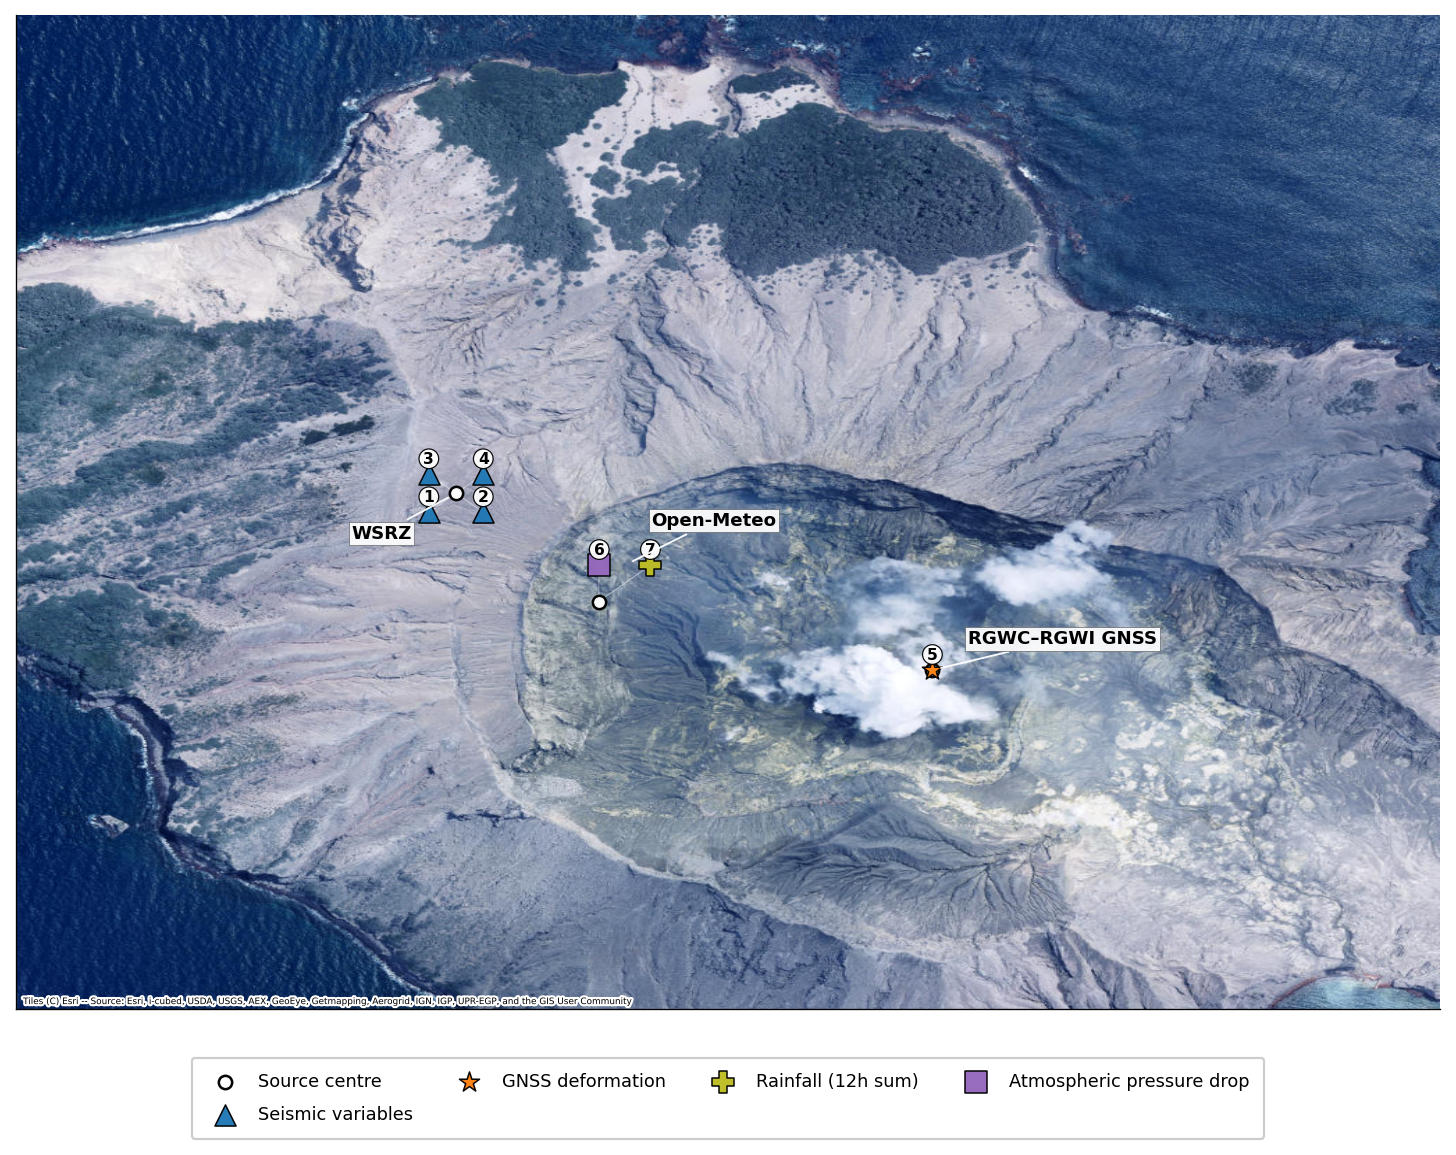

In [10]:
whakaari_meta = whakaari_observable_metadata()

fig, ax, whakaari_variable_table = plot_whakaari_all_variables_map(
    metadata=whakaari_meta,
    satellite=True, # True for satellite imagery
    save_dir="figures",
    filename="whakaari_map",
)

whakaari_variable_table